In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1️⃣ Load dataset
airlines = pd.read_csv("AirlinesCluster.csv")

# 2️⃣ Select numeric columns only (exclude non-numeric like IDs or names)
num_cols = airlines.select_dtypes(include=np.number).columns.tolist()

# 3️⃣ Manually compute mean and std
pp_mean = airlines[num_cols].mean()
pp_std = airlines[num_cols].std(ddof=1)  # same as R's default

# 4️⃣ Standardize manually
airline_scaled = (airlines[num_cols] - pp_mean) / pp_std

# 5️⃣ Run K-Means (k = 8, iter.max = 100, set.seed(144), add n_init = 40)
kmeans = KMeans(n_clusters=8, random_state=144, n_init=50)
kmeans.fit(airline_scaled)

# 6️⃣ Add cluster assignments to dataset
airlines["cluster"] = kmeans.labels_ + 1  # +1 to match R’s 1–8 labeling

# 7️⃣ Compute standardized cluster centers (like t(round(mod$centers, 2)))
centers_std = pd.DataFrame(kmeans.cluster_centers_, columns=num_cols).T.round(2)
centers_std.columns = [1,2,3,4,5,6,7,8]

# 8️⃣ Back-transform to original units (like round(t(mod$centers)*pp$std + pp$mean))
centers_orig = (centers_std * pp_std.values.reshape(-1,1) + pp_mean.values.reshape(-1,1)).round(0)

# 9️⃣ Cluster sizes (like table(mod$cluster))
cluster_sizes = airlines["cluster"].value_counts().sort_index()

# 10️⃣ Display results
print("=== Standardized Cluster Centers ===")
print(centers_std)
print("\n=== Original Scale Cluster Centers ===")
print(centers_orig)
print("\n=== Cluster Sizes ===")
print(cluster_sizes)


=== Standardized Cluster Centers ===
                    1     2     3     4     5     6     7     8
Balance          0.30 -0.35 -0.17  5.99  0.41  0.76  0.77 -0.42
BonusMiles       0.21 -0.58  0.08  2.09  0.16  2.24  0.86 -0.61
BonusTrans       0.47 -0.75  0.54  1.11  0.83  1.13  2.49 -0.86
FlightMiles     -0.18 -0.22 -0.24  0.80  1.88 -0.09  5.84 -0.24
FlightTrans     -0.19 -0.23 -0.26  1.11  1.92 -0.06  6.07 -0.24
DaysSinceEnroll  1.02  0.70 -0.65  1.17  0.03  0.47  0.15 -1.02

=== Original Scale Cluster Centers ===
                        1        2        3         4         5         6  \
Balance          103834.0  38330.0  56469.0  677248.0  114919.0  150191.0   
BonusMiles        22217.0   3137.0  19077.0   67620.0   21009.0   71243.0   
BonusTrans           16.0      4.0     17.0      22.0      20.0      22.0   
FlightMiles         208.0    152.0    124.0    1580.0    3092.0     334.0   
FlightTrans           1.0      1.0      0.0       6.0       9.0       1.0   
DaysSinceEnro

In [2]:
centers_std

,1,2,3,4,5,6,7,8
Balance,0.30,-0.35,-0.17,5.99,0.41,0.76,0.77,-0.42
BonusMiles,0.21,-0.58,0.08,2.09,0.16,2.24,0.86,-0.61
BonusTrans,0.47,-0.75,0.54,1.11,0.83,1.13,2.49,-0.86
FlightMiles,-0.18,-0.22,-0.24,0.80,1.88,-0.09,5.84,-0.24
FlightTrans,-0.19,-0.23,-0.26,1.11,1.92,-0.06,6.07,-0.24
DaysSinceEnroll,1.02,0.70,-0.65,1.17,0.03,0.47,0.15,-1.02


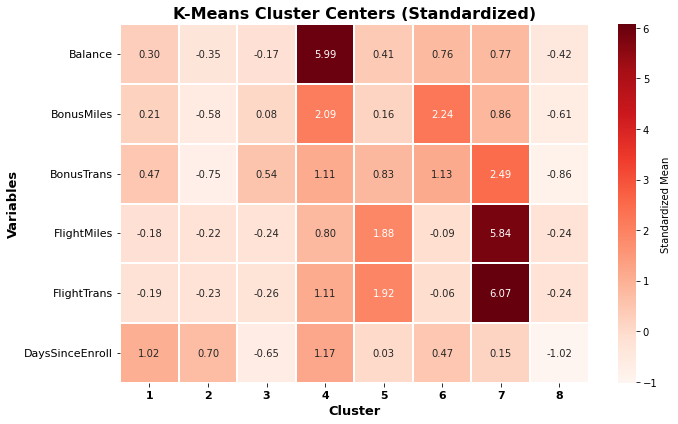

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset previous grid styles
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.facecolor"] = "white"

# --- Draw heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(
    centers_std.iloc[:],
    annot=True,
    fmt=".2f",
    cmap="Reds",  # 🔥 use 'Reds' or 'RdPu' for warm red tone
    cbar_kws={'label': 'Standardized Mean'},
    linewidths=0.2,
    linecolor='white'
)

# --- Styling ---
plt.title("K-Means Cluster Centers (Standardized)", fontsize=16, weight='bold')
plt.xlabel("Cluster", fontsize=13, weight='bold')
plt.ylabel("Variables", fontsize=13, weight='bold')
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()



In [4]:

# 2, 6 - low activity
# 1, 3, 8 - bonusMiles
# 4, 5 - frequent traveller
# 7 - elite

/Users/pengsun/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/pengsun/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/pengsun/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/pengsun/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


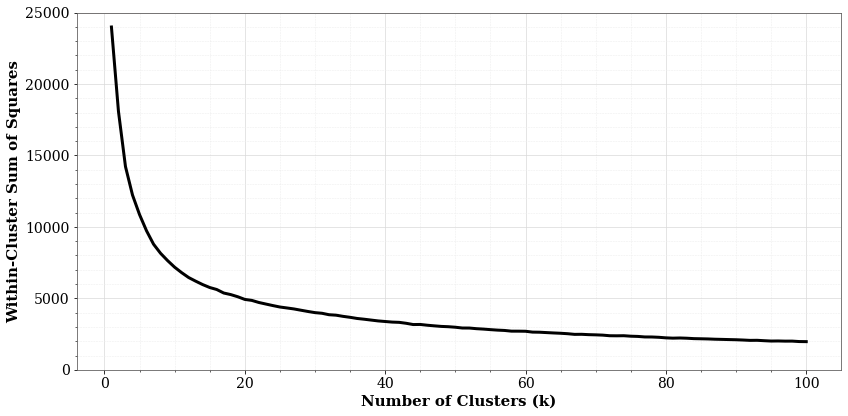

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Compute WCSS ---
wcss = []
for k in range(1, 101):
    kmeans = KMeans(n_clusters=k, max_iter=100, random_state=144)
    kmeans.fit(airline_scaled)
    wcss.append(kmeans.inertia_)

dat = pd.DataFrame({'k': range(1, 101), 'SS': wcss})

# --- Global ggplot-like style ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Palatino", "Book Antiqua", "URW Palladio L"],
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.grid": True,
    "grid.color": "#D9D9D9",
    "grid.linewidth": 0.7,
    "axes.edgecolor": "#5C5A5A"
})

# --- Plot on single figure ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(dat["k"], dat["SS"], color="black", linewidth=3)
ax.set_xlabel("Number of Clusters (k)", fontsize=15, weight='bold')
ax.set_ylabel("Within-Cluster Sum of Squares", fontsize=15, weight='bold')
ax.set_ylim(0, 25000)

# Grid style (like theme_bw)
ax.grid(True, which="major", color="#D9D9D9", linewidth=0.7)
ax.grid(True, which="minor", color="#ECECEC", linewidth=0.5, linestyle='--')
ax.minorticks_on()
ax.tick_params(axis='both', direction='out')

plt.tight_layout()
plt.show()

# Optional: high-res EPS export
fig.savefig("p46.svg")


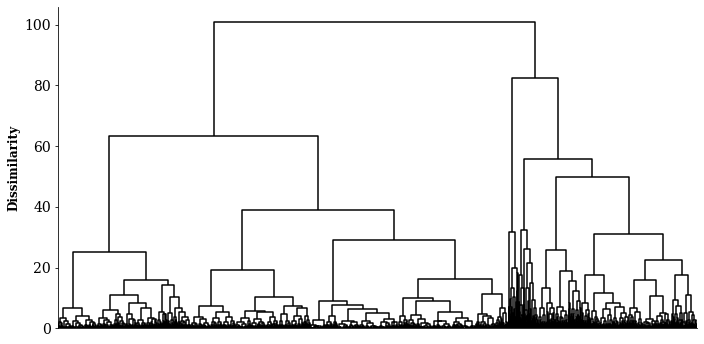

✅ Saved as final_dendrogram_black.svg


In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Compute all-pair Euclidean distances
distances = pdist(airline_scaled, metric='euclidean')

# Build the hierarchical clustering model
hclust_model = linkage(distances, method='ward')

# --- Plot the dendrogram (all black) ---
plt.figure(figsize=(10, 5))
dendrogram(
    hclust_model,
    no_labels=True,
    above_threshold_color="black",  # all links black
    color_threshold=0               # force single color
)

plt.ylabel("Dissimilarity", fontsize=12, weight="bold", color="black")

# --- Style ---
ax = plt.gca()
ax.tick_params(colors="black")
ax.spines["top"].set_visible(False)     # remove top border
ax.spines["right"].set_visible(False)   # remove right border
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
plt.grid(False)

# --- Save and show ---
plt.tight_layout()
plt.savefig("p74.svg", format="svg", bbox_inches="tight")
plt.show()
print("✅ Saved as final_dendrogram_black.svg")


🔹 Dissimilarity thresholds and corresponding cluster counts:
   dissimilarity  nclust
0             75       3
1             50       5
2             32       8
3             25      14
4             20      16
5             15      27
✅ Saved p75_1.svg


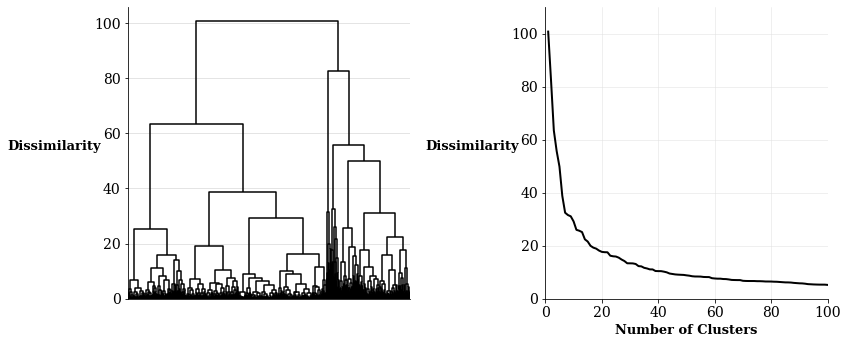

✅ Saved p75_2.svg


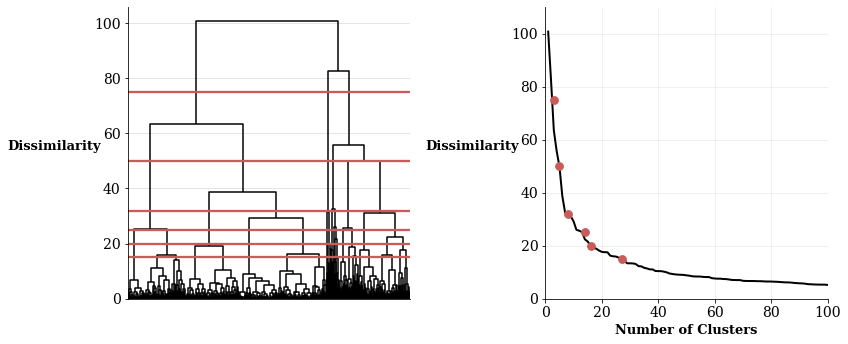

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# === Load your scaled dataset ===
# Replace with your actual DataFrame name
X = airline_scaled.values  # must be numeric and standardized

# === Hierarchical clustering (Ward) ===
distances = pdist(X, metric='euclidean')
hclust_model = linkage(distances, method='ward')

# === Scree plot data ===
dat_hc_airline = pd.DataFrame({
    "nclust": np.arange(1, len(hclust_model) + 1),
    "dissimilarity": hclust_model[:, 2][::-1]
})

# === Parameters ===
dissimilarity_all = [75, 50, 32, 25, 20, 15]  # user-defined dissimilarity thresholds
highlight_color = "#c95b5b"                   # softer red
text_color = "#6a0f0f"

# === Function to find number of clusters at given dissimilarity ===
def num_clusters_at_threshold(Z, threshold):
    """Return number of clusters remaining when cutting tree at given dissimilarity."""
    labels = fcluster(Z, t=threshold, criterion='distance')
    return len(np.unique(labels))

# Compute cluster counts dynamically
cluster_info = pd.DataFrame({
    "dissimilarity": dissimilarity_all,
    "nclust": [num_clusters_at_threshold(hclust_model, t) for t in dissimilarity_all]
})
print("🔹 Dissimilarity thresholds and corresponding cluster counts:")
print(cluster_info)

# === Function to draw combined plot ===
def plot_combined(before_lines=True, filename="combined.svg"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1]})

    ax1.set_ylim(0, 110)
    # ----- Left: dendrogram -----
    dendrogram(
        hclust_model,
        no_labels=True,
        above_threshold_color="black",
        color_threshold=0,
        ax=ax1
    )

    ax1.set_ylabel("Dissimilarity", fontsize=13, weight="bold", rotation=0, labelpad=40)
    ax1.yaxis.set_label_position("left")
    ax1.tick_params(colors="black")
    for spine in ["top", "right"]:
        ax1.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax1.spines[spine].set_color("black")

    if not before_lines:
        for y in dissimilarity_all:
            ax1.axhline(y=y, color=highlight_color, linewidth=2.3)

    # ----- Right: Scree plot -----
    ax2.plot(dat_hc_airline["nclust"], dat_hc_airline["dissimilarity"],
             color="black", linewidth=2)
    ax2.set_xlabel("Number of Clusters", fontsize=13, weight="bold")
    ax2.set_ylabel("Dissimilarity", fontsize=13, weight="bold", rotation=0, labelpad=40)
    ax2.yaxis.set_label_position("left")
    ax2.set_xlim(0, 100)
    ax2.set_ylim(0, 110)
    ax2.grid(True, linewidth=0.5, color="#E0E0E0")

    if not before_lines:
        # draw the red dots computed dynamically
        ax2.scatter(cluster_info["nclust"], cluster_info["dissimilarity"],
                    color=highlight_color, s=60, zorder=5)

    for spine in ["top", "right"]:
        ax2.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax2.spines[spine].set_color("black")
    ax2.tick_params(colors="black")

    plt.tight_layout()
    plt.savefig(filename, format="svg", bbox_inches="tight")
    print(f"✅ Saved {filename}")
    plt.show()

# === Draw both versions ===
plot_combined(before_lines=True, filename="p75_1.svg")
plot_combined(before_lines=False, filename="p75_2.svg")


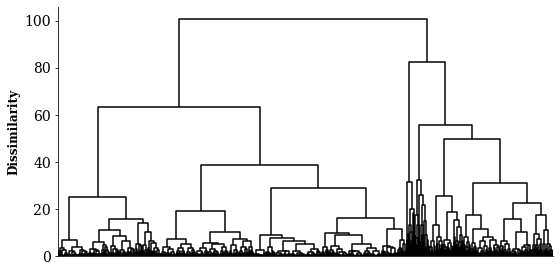

✅ p76.svg


In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Compute all-pair Euclidean distances
distances = pdist(airline_scaled, metric='euclidean')

# Build the hierarchical clustering model
hclust_model = linkage(distances, method='ward')

# --- Plot the dendrogram (all black) ---
plt.figure(figsize=(8, 4))
dendrogram(
    hclust_model,
    no_labels=True,
    above_threshold_color="black",  # all links black
    color_threshold=0               # force single color
)

plt.ylabel("Dissimilarity", fontsize=12, weight="bold", color="black")

# --- Style ---
ax = plt.gca()
ax.tick_params(colors="black")
ax.spines["top"].set_visible(False)     # remove top border
ax.spines["right"].set_visible(False)   # remove right border
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
plt.grid(False)

# --- Save and show ---
plt.tight_layout()
plt.savefig("p76.svg", format="svg", bbox_inches="tight")
plt.show()
print("✅ p76.svg")

In [9]:
# print the color the dendrogram with 7 clusters and also print the size of each cluster
labels = fcluster(hclust_model, t=7, criterion='maxclust')
cluster_sizes = pd.Series(labels).value_counts().sort_index()
print("Cluster sizes with 7 clusters:")
print(cluster_sizes)

Cluster sizes with 7 clusters:
1     833
2     746
3    1242
4      63
5     121
6     271
7     723
dtype: int64


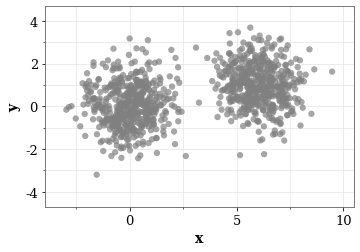

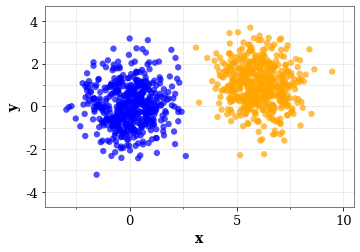

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# === 1. Data generation ===
np.random.seed(2022)
x = np.concatenate([np.random.normal(0, 1, 500), np.random.normal(6, 1, 500)])
y = np.concatenate([np.random.normal(0, 1, 500), np.random.normal(1, 1, 500)])
newdat = pd.DataFrame({"x": x, "y": y})

# === 2. Global ggplot-like style ===
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Palatino", "Book Antiqua", "URW Palladio L"],
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "axes.edgecolor": "#5C5A5A",
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.7
})

# === 3. Axis limits and ticks ===
x_min, x_max = newdat["x"].min() - 1, newdat["x"].max() + 1
y_min, y_max = newdat["y"].min() - 1, newdat["y"].max() + 1

x_ticks_minor = np.arange(np.floor(x_min / 2.5) * 2.5, x_max + 2.5, 2.5)
x_ticks_major = np.arange(np.floor(x_min / 5) * 5, x_max + 5, 5)
y_ticks_minor = np.arange(np.floor(y_min), y_max + 1, 1)
y_ticks_major = np.arange(np.floor(y_min / 2) * 2, y_max + 2, 2)

# === 4. Scatter before clustering ===
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(newdat["x"], newdat["y"], s=40, color="gray", alpha=0.7, edgecolor="none")

# Set ticks
ax.set_xticks(x_ticks_major)
ax.set_xticks(x_ticks_minor, minor=True)
ax.set_xticklabels([str(int(tick)) for tick in x_ticks_major])
ax.set_yticks(y_ticks_major)
ax.set_yticks(y_ticks_minor, minor=True)
ax.set_yticklabels([str(int(tick)) for tick in y_ticks_major])

# Axis limits and labels
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min-0.5, y_max)
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)

# Grid styling — grid only on minor ticks (behind points)
ax.set_axisbelow(True)
ax.grid(True, which="minor", color="#E5E5E5", linewidth=0.7)


# Frame and aspect
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig("p78_1.svg", format="svg", bbox_inches="tight")
plt.show()


# === 3. Apply k-means clustering ===
modnew = KMeans(n_clusters=2, max_iter=100, random_state=2022, n_init=10)
newdat["cluster"] = modnew.fit_predict(newdat[["x", "y"]])

# === 4. Scatter after clustering ===
cluster_colors = {0: "orange", 1: "blue"}

fig, ax = plt.subplots(figsize=(5.2, 5))
for cid, color in cluster_colors.items():
    subset = newdat[newdat["cluster"] == cid]
    ax.scatter(subset["x"], subset["y"], s=40, color=color, alpha=0.7, edgecolor="none")

# Set ticks
ax.set_xticks(x_ticks_major)
ax.set_xticks(x_ticks_minor, minor=True)
ax.set_xticklabels([str(int(tick)) for tick in x_ticks_major])
ax.set_yticks(y_ticks_major)
ax.set_yticks(y_ticks_minor, minor=True)
ax.set_yticklabels([str(int(tick)) for tick in y_ticks_major])

# Axis limits and labels
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min-0.5, y_max)
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
ax.set_aspect("equal", adjustable="box")

# Grid styling — grid only on minor ticks (behind points)
ax.set_axisbelow(True)
ax.grid(True, which="minor", color="#E5E5E5", linewidth=0.7)

plt.tight_layout()
plt.savefig("p78_2.svg", format="svg", bbox_inches="tight")
plt.show()



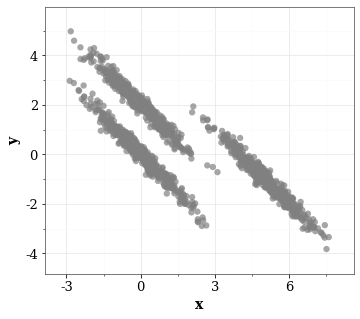

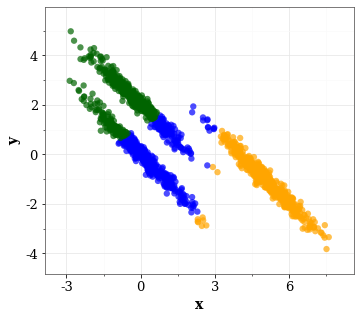

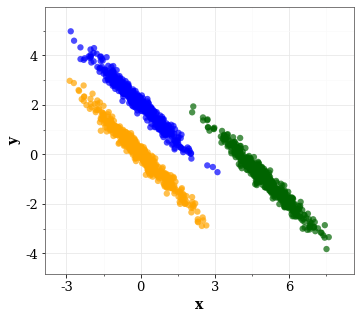

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# ======================
# 1. Data generation
# ======================
np.random.seed(2020)
x = np.concatenate([
    np.random.normal(0, 1, 500),
    np.random.normal(0, 1, 500),
    np.random.normal(5, 1, 500)
])
y = -x + np.concatenate([
    np.random.normal(0, 0.2, 500),
    2 + np.random.normal(0, 0.2, 500),
    4 + np.random.normal(0, 0.2, 500)
])

newdat = pd.DataFrame({"x": x, "y": y})

# ======================
# 2. Global ggplot-like style
# ======================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Palatino", "Book Antiqua", "URW Palladio L"],
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "axes.edgecolor": "#5C5A5A",
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.7
})

# === Axis setup ===
x_min, x_max = newdat["x"].min() - 1, newdat["x"].max() + 1
y_min, y_max = newdat["y"].min() - 1, newdat["y"].max() + 1
x_ticks_minor = np.arange(np.floor(x_min / 1.5) * 1.5, x_max + 1.5, 1.5)
x_ticks_major = np.arange(np.floor(x_min / 3) * 3, x_max + 3, 3)
y_ticks_minor = np.arange(np.floor(y_min), y_max + 1, 1)
y_ticks_major = np.arange(np.floor(y_min / 2) * 2, y_max + 2, 2)

# Color palette to match R
cluster_colors = {0: "orange", 1: "blue", 2: "darkgreen"}

def setup_axes(ax):
    ax.set_xticks(x_ticks_major)
    ax.set_xticks(x_ticks_minor, minor=True)
    ax.set_xticklabels([str(int(tick)) for tick in x_ticks_major])
    ax.set_yticks(y_ticks_major)
    ax.set_yticks(y_ticks_minor, minor=True)
    ax.set_yticklabels([str(int(tick)) for tick in y_ticks_major])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    ax.set_axisbelow(True)
    ax.grid(True, which="minor", color="#FAFAFA", linewidth=0.7)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.set_aspect("equal", adjustable="box")

# ======================
# 3. Raw data plot
# ======================
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(newdat["x"], newdat["y"], s=40, color="gray", alpha=0.7, edgecolor="none")
setup_axes(ax)
plt.tight_layout()
plt.savefig("p80_.svg", format="svg", bbox_inches="tight")
plt.show()

# ======================
# 4. K-Means clustering
# ======================
np.random.seed(1562)
mod_kmeans = KMeans(n_clusters=3, max_iter=100, random_state=1562, n_init=10)
newdat["kmeans_cluster"] = mod_kmeans.fit_predict(newdat[["x", "y"]])

fig, ax = plt.subplots(figsize=(5.2, 5))
for cid, color in cluster_colors.items():
    subset = newdat[newdat["kmeans_cluster"] == cid]
    ax.scatter(subset["x"], subset["y"], s=40, color=color, alpha=0.7, edgecolor="none")
setup_axes(ax)
plt.tight_layout()
plt.savefig("p80_2.svg", format="svg", bbox_inches="tight")
plt.show()

# ======================
# 5. Gaussian Mixture Model (VVV / full covariance)
# ======================

# Color palette to match R
cluster_colors = {1: "orange", 2: "blue", 0: "darkgreen"}
np.random.seed(1562)
mod_gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=1562)
newdat["gmm_cluster"] = mod_gmm.fit_predict(newdat[["x", "y"]])

fig, ax = plt.subplots(figsize=(5.2, 5))
for cid, color in cluster_colors.items():
    subset = newdat[newdat["gmm_cluster"] == cid]
    ax.scatter(subset["x"], subset["y"], s=40, color=color, alpha=0.7, edgecolor="none")
setup_axes(ax)
plt.tight_layout()
plt.savefig("p87_3.svg", format="svg", bbox_inches="tight")
plt.show()


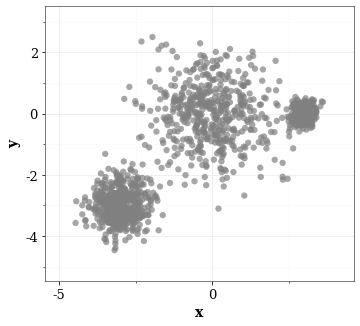

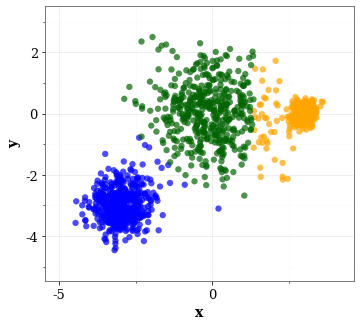

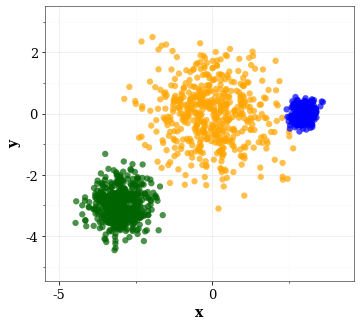

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# ======================
# 1. Data generation
# ======================
np.random.seed(2020)
x = np.concatenate([
    np.random.normal(0, 1, 500),
    np.random.normal(3, 0.2, 500),
    np.random.normal(-3, 0.5, 500)
])
y = np.concatenate([
    np.random.normal(0, 1, 500),
    np.random.normal(0, 0.2, 500),
    np.random.normal(-3, 0.5, 500)
])
newdat = pd.DataFrame({"x": x, "y": y})

# ======================
# 2. Global ggplot-like style
# ======================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Palatino", "Book Antiqua", "URW Palladio L"],
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "axes.edgecolor": "#5C5A5A",
    "grid.color": "#E5E5E5",   # ultra-light pastel grid
    "grid.linewidth": 0.6
})

# === Axis setup ===
x_min, x_max = newdat["x"].min() - 1, newdat["x"].max() + 1
y_min, y_max = newdat["y"].min() - 1, newdat["y"].max() + 1
x_ticks_minor = np.arange(np.floor(x_min / 2.5) * 2.5, x_max + 2.5, 2.5)
x_ticks_major = np.arange(np.floor(x_min / 5) * 5, x_max + 5, 5)
y_ticks_minor = np.arange(np.floor(y_min), y_max + 1, 1)
y_ticks_major = np.arange(np.floor(y_min / 2) * 2, y_max + 2, 2)

# Color mapping
cluster_colors = {0: "orange", 1: "blue", 2: "darkgreen"}

def setup_axes(ax):
    ax.set_xticks(x_ticks_major)
    ax.set_xticks(x_ticks_minor, minor=True)
    ax.set_xticklabels([str(int(tick)) for tick in x_ticks_major])
    ax.set_yticks(y_ticks_major)
    ax.set_yticks(y_ticks_minor, minor=True)
    ax.set_yticklabels([str(int(tick)) for tick in y_ticks_major])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    ax.set_axisbelow(True)
    ax.grid(True, which="minor", color="#FAFAFA", linewidth=0.7)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.set_aspect("equal", adjustable="box")

# ======================
# 3. Raw data
# ======================
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(newdat["x"], newdat["y"], s=40, color="gray", alpha=0.7, edgecolor="none")
setup_axes(ax)
plt.tight_layout()
plt.savefig("p81.svg", format="svg", bbox_inches="tight")
plt.show()

# ======================
# 4. K-means clustering
# ======================
np.random.seed(1562)
mod_kmeans = KMeans(n_clusters=3, max_iter=100, random_state=1562, n_init=10)
newdat["kmeans_cluster"] = mod_kmeans.fit_predict(newdat[["x", "y"]])

fig, ax = plt.subplots(figsize=(5.2, 5))
for cid, color in cluster_colors.items():
    subset = newdat[newdat["kmeans_cluster"] == cid]
    ax.scatter(subset["x"], subset["y"], s=40, color=color, alpha=0.7, edgecolor="none")
setup_axes(ax)
plt.tight_layout()
plt.savefig("p81_2.svg", format="svg", bbox_inches="tight")
plt.show()

# ======================
# 5. Gaussian Mixture Model (VVV / full covariance)
# ======================
cluster_colors = {2: "orange", 1: "blue", 0: "darkgreen"}
np.random.seed(1562)
mod_gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=1562)
newdat["gmm_cluster"] = mod_gmm.fit_predict(newdat[["x", "y"]])

# Reorder cluster colors to match your R version (1=orange, 3=blue, 2=darkgreen)
cluster_order = {1: "orange", 2: "blue", 0: "darkgreen"}

fig, ax = plt.subplots(figsize=(5.2, 5))
for cid, color in cluster_order.items():
    subset = newdat[newdat["gmm_cluster"] == cid]
    ax.scatter(subset["x"], subset["y"], s=40, color=color, alpha=0.7, edgecolor="none")
setup_axes(ax)
plt.tight_layout()
plt.savefig("p88_3.svg", format="svg", bbox_inches="tight")
plt.show()


In [13]:
def show_head_tail(df, n=3, m=3, decimals=None):
    """
    Displays the head and tail of a DataFrame separated by an ellipsis.

    Args:
        df (pd.DataFrame): The DataFrame to display.
        n (int): Number of rows to show for the head.
        m (int): Number of rows to show for the tail.
        decimals (int, optional): Number of decimal places for numeric values.
                                  If None, original precision is preserved.
    """
    if not isinstance(df, pd.DataFrame):
        print("Input must be a pandas DataFrame.")
        return

    # Optionally round numeric columns
    if decimals is not None:
        df_display = df.copy()
        numeric_cols = df_display.select_dtypes(include=['float64', 'int64']).columns
        df_display[numeric_cols] = df_display[numeric_cols].round(decimals)
    else:
        df_display = df

    # Create a separator DataFrame filled with '...'
    separator = pd.DataFrame([['...'] * len(df_display.columns)],
                             columns=df_display.columns,
                             index=['...'])

    # Concatenate head, separator, and tail
    combined_df = pd.concat([df_display.head(n), separator, df_display.tail(m)])
    display(combined_df)


In [16]:
show_head_tail(airlines, 10, 5)

,Balance,BonusMiles,BonusTrans,FlightMiles,FlightTrans,DaysSinceEnroll,cluster
0,48296,31329,9,500,1,3061,3
1,10021,0,0,0,0,7879,2
2,49280,22370,16,0,0,3312,3
3,213539,2750,15,0,0,4751,1
4,125465,14750,9,0,0,7206,1
5,7698,0,0,0,0,1734,8
6,201259,40755,34,0,0,3398,6
7,350608,50988,26,2643,5,3630,5
8,146232,83783,19,375,1,3566,6
9,2080,0,0,0,0,4635,2


In [18]:
show_head_tail(airline_scaled, 10, 5, 2)

,Balance,BonusMiles,BonusTrans,FlightMiles,FlightTrans,DaysSinceEnroll
0,-0.25,0.59,-0.27,0.03,-0.1,-0.51
1,-0.63,-0.71,-1.21,-0.33,-0.36,1.82
2,-0.24,0.22,0.46,-0.33,-0.36,-0.39
3,1.39,-0.6,0.35,-0.33,-0.36,0.31
4,0.51,-0.1,-0.27,-0.33,-0.36,1.5
5,-0.65,-0.71,-1.21,-0.33,-0.36,-1.15
6,1.27,0.98,2.33,-0.33,-0.36,-0.35
7,2.75,1.4,1.5,1.56,0.96,-0.24
8,0.72,2.76,0.77,-0.06,-0.1,-0.27
9,-0.71,-0.71,-1.21,-0.33,-0.36,0.25
